In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt

# для colab
# from google.colab import drive
# import sys
# sys.path.append('/content/drive/MyDrive')

from model import SASRecModel, negative_sampling_loss

In [2]:
data = torch.load('preprocessed_data.pt')

# для colab
# data = torch.load('/content/drive/MyDrive/preprocessed_data.pt')

C:\Users\1\AppData\Local\Temp\ipykernel_25508\2643031679.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('preprocessed_data.pt')


In [3]:
print(data['train_inputs'][:3])

tensor([[     0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0, 341720],
        [     0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0, 341720, 288670],
        [     0,      0,      0,      0,      0,      0,      0,      0,      0,
         

In [4]:
print(data.keys())

dict_keys(['train_inputs', 'train_targets', 'train_weights', 'validate_inputs', 'validate_targets', 'validate_weights', 'test_inputs', 'test_targets', 'test_weights', 'cnt_item', 'track_to_index'])


In [5]:
def ndcg_at_k(rel, pred, k=10):
    # метрика NDCG@k
    ndcg = 0.0
    if rel in pred[:k]:
        pred_list = list(pred[:k])
        score = pred_list.index(rel) + 1
        ndcg = 1.0 / np.log2(score + 1)
        return ndcg
    return ndcg


def recall_at_k(rel, pred, k=10):
    # метрика Recall@k
    recall = 1.0 if rel in pred[:k] else 0.0
    return recall

In [6]:
train_inputs, train_targets, train_weights = data['train_inputs'], data['train_targets'], data['train_weights']
validate_inputs, validate_targets = data['validate_inputs'], data['validate_targets']
cnt_item = data['cnt_item']

print(f"Train: {len(train_inputs)} примеров")
print(f"Validate: {len(validate_inputs)} примеров")

Train: 305682 примеров
Validate: 65590 примеров


In [7]:
batch_size = 32
train_dataset = TensorDataset(train_inputs, train_targets, train_weights)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True)
                           # num_workers=2)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SASRecModel(cnt_item=cnt_item, max_seq_len=50,
                     hidden_dim=64, num_heads=2, num_layers=2, dropout=0.2).to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Параметров: 81,502,940


In [10]:
def check_metrics_validate(model, validate_inputs, validate_targets, k=10, batch_size=16):
    # расчет метрик на валидационной выборке
    model.eval()
    ndcg_scores, recall_scores = [], []

    with torch.no_grad():
         for i in tqdm(range(0, len(validate_inputs), batch_size), desc="Validate"):
            batch_input = validate_inputs[i:i+batch_size].to(device)
            batch_target = validate_targets[i:i+batch_size]

            logits = model(batch_input)
            scores = logits[:, -1, :]
            _, pred = torch.topk(scores, k=k, dim=1)
            pred = pred.cpu().numpy()

            for j in range(len(batch_target)):
              target = batch_target[j].item()
              ndcg_scores.append(ndcg_at_k(target, pred[j], k))
              recall_scores.append(recall_at_k(target, pred[j], k))

    model.train()
    return np.mean(ndcg_scores), np.mean(recall_scores)

In [11]:
from torch.amp import GradScaler, autocast

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler('cuda')
os.makedirs('checkpoints', exist_ok=True)

best_ndcg = 0.0
#проверяем метрики на валидации каждые 2 эпохи
check_validate = 2

patience = 2
patience_counter = 0

# для графиков
history = {
    'epoch': [],
    'train_loss': [],
    'validate_ndcg': [],
    'validate_recall': []
}


for epoch in range(1, 13):
    # обучение
    model.train()
    total_loss = 0

    for inputs, targets, weights in tqdm(train_loader, desc=f"Epoch {epoch}/12"):
        inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)

        with autocast('cuda'):
            logits = model(inputs)
            loss = negative_sampling_loss(logits[:, -1, :], targets, weights, cnt_item)

        optimizer.zero_grad()
        scaler.scale(loss).backward()   # масштабируем loss для устойчивости
        scaler.step(optimizer)          # шаг оптимизатора
        scaler.update()                 # обновляем scaler

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)

    # валидация
    if epoch % check_validate == 0:
        validate_ndcg, validate_recall = check_metrics_validate(model, validate_inputs, validate_targets, k=10, batch_size=32)
        history['validate_ndcg'].append(validate_ndcg)
        history['validate_recall'].append(validate_recall)

        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f} | Validate NDCG@10: {validate_ndcg:.4f} | Validate Recall@10: {validate_recall:.4f}', flush=True)

        if validate_ndcg > best_ndcg:
            best_ndcg = validate_ndcg
            patience_counter = 0
            torch.save(model.state_dict(), 'checkpoints/sasrec_best.pth')
            print(f'Лучшая модель сохранена (NDCG@10: {best_ndcg:.4f})', flush=True)
        else:
            patience_counter += 1
            print(f'Нет улучшения ({patience_counter}/{patience})', flush=True)

        if patience_counter >= patience:
            print(f'Ранняя остановка на эпохе {epoch}', flush=True)
            break

    else:
        history['validate_ndcg'].append(None)
        history['validate_recall'].append(None)
        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f}', flush=True)

print(f'Лучшая метрика NDCG@10 на валидации: {best_ndcg:.4f}', flush=True)

Epoch 1/12: 100%|██████████| 9553/9553 [14:28<00:00, 11.00it/s]

Epoch  1 | Train Loss: 5.7723



Validate: 100%|██████████| 2050/2050 [10:30<00:00,  3.25it/s]

Epoch  2 | Train Loss: 2.8170 | Validate NDCG@10: 0.0062 | Validate Recall@10: 0.0132


Лучшая модель сохранена (NDCG@10: 0.0062)


...

Epoch 11/12: 100%|██████████| 9553/9553 [13:46<00:00, 11.56it/s]

Epoch 11 | Train Loss: 0.5862



Validate: 100%|██████████| 2050/2050 [10:26<00:00,  3.27it/s]

Epoch 12 | Train Loss: 0.5164 | Validate NDCG@10: 0.0135 | Validate Recall@10: 0.0258


Лучшая модель сохранена (NDCG@10: 0.0135)
Лучшая метрика NDCG@10 на валидации: 0.0135


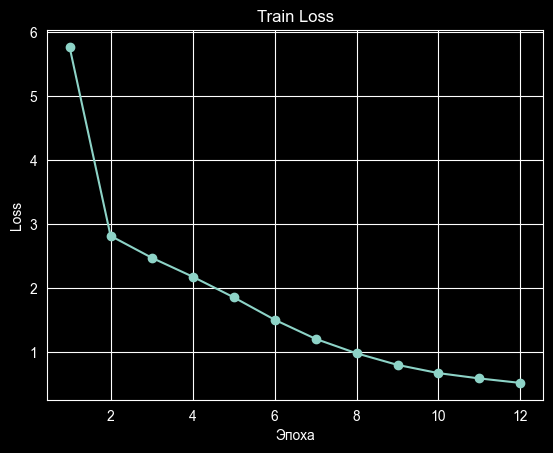

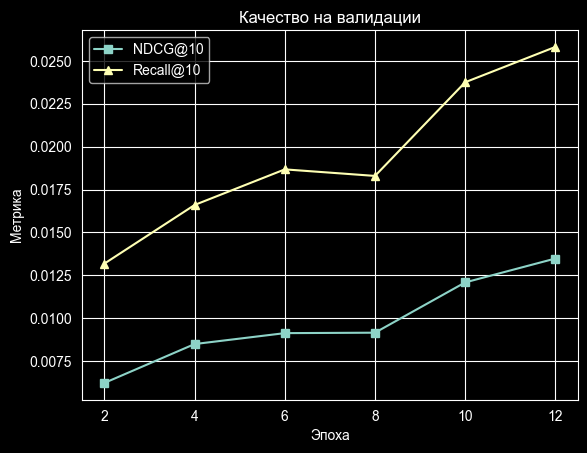

In [12]:
# графики для потерь и метрики
plt.figure()
plt.plot(history['epoch'], history['train_loss'], marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Train Loss')
plt.grid(True)
plt.show()

validate_epochs = [v for v, i in zip(history['epoch'], history['validate_ndcg']) if i is not None]
validate_ndcg_clean = [i for i in history['validate_ndcg'] if i is not None]
validate_recall_clean = [i for i in history['validate_recall'] if i is not None]

plt.figure()
plt.plot(validate_epochs, validate_ndcg_clean, marker='s', label='NDCG@10')
plt.plot(validate_epochs, validate_recall_clean, marker='^', label='Recall@10')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.title('Качество на валидации')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# метрика на тесте
test_inputs = data['test_inputs']
test_targets = data['test_targets']
top_k_values = [10, 50, 100]

model.load_state_dict(torch.load('checkpoints/sasrec_best.pth', map_location=device))
model.eval()

ndcg_scores = {k: [] for k in top_k_values}
recall_scores = {k: [] for k in top_k_values}

with torch.no_grad():
    for i in tqdm(range(len(test_inputs)), desc='Тест'):
        inp = test_inputs[i].unsqueeze(0).to(device)
        target = test_targets[i].item()
        scores = model(inp)[0, -1, :].cpu().numpy()
        pred = np.argsort(scores)[::-1][:max(top_k_values)]
        for k in top_k_values:
            ndcg_scores[k].append(ndcg_at_k(target, pred, k))
            recall_scores[k].append(recall_at_k(target, pred, k))

for k in top_k_values:
    print(f'NDCG@{k:<3}   {np.mean(ndcg_scores[k]):.4f}')
    print(f'Recall@{k:<3} {np.mean(recall_scores[k]):.4f}')
    print()

C:\Users\1\AppData\Local\Temp\ipykernel_25508\759669326.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('checkpoints/sasrec_best.pth', m

NDCG@10    0.0137
Recall@10  0.0257

NDCG@50    0.0221
Recall@50  0.0649

NDCG@100   0.0269
Recall@100 0.0945

